# Post-train evaluation — DPLM training run

Visualizes the post-training evaluation results for a single DPLM training run.
Set `RUN_DIR` in the configuration cell below to point at the run you want to inspect.

For each available N-Step checkpoint we look at the generated sequences saved under
`<RUN_DIR>/post_train_evaluation/step_<N>/` on three axes:

1. **EnzymeExplorer (sequence-only) classifier** — `isTPS` probability + per-substrate predictions.
2. **Max sequence identity vs the training set** + intra-set self-identity (mode-collapse signal).
3. **Motif occurrence** for the canonical TPS motifs (`DD..D`, `(N|D)D(L|I|V).(S|T)...E`).

Inputs live next to each step's `generated_sequences.fasta`. The notebook degrades
gracefully if any per-step CSV is missing.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# --- CONFIGURATION ---
# Edit RUN_DIR to point at the training run you want to visualize.
RUN_DIR = Path(
    "/mnt/proj2/fta-26-15/documents/dplm/logs/"
    "TPS_dplm_150m_stage3_grid_run_41_lr1em3_wu2000_ts200000_ckpt10000_valee10000_lend0p0001_winit1em06_loratrue_ns50_r1_a2_ltmV"
)

EVAL_ROOT = RUN_DIR / "post_train_evaluation"
STEPS = sorted(int(p.name.split("_", 1)[1]) for p in EVAL_ROOT.glob("step_*") if p.is_dir())
print(f"RUN_DIR: {RUN_DIR.name}")
print(f"Found {len(STEPS)} step folders: head={STEPS[:3]} tail={STEPS[-3:]}")


RUN_DIR: TPS_dplm_150m_stage3_grid_run_41_lr1em3_wu2000_ts200000_ckpt10000_valee10000_lend0p0001_winit1em06_loratrue_ns50_r1_a2_ltmV
Found 20 step folders: head=[10000, 20000, 30000] tail=[180000, 190000, 200000]


In [3]:
def _load(step, suffix):
    fp = EVAL_ROOT / f"step_{step}" / f"generated_sequences{suffix}.csv"
    if not fp.exists():
        return None
    try:
        return pd.read_csv(fp)
    except Exception as e:
        print(f"[warn] failed to load {fp}: {e}")
        return None

ee        = {s: _load(s, "_enzyme_explorer_sequence_only") for s in STEPS}
msi_train = {s: _load(s, "_max_sequence_identity") for s in STEPS}
msi_self  = {s: _load(s, "_max_sequence_identity_self") for s in STEPS}
motif     = {s: _load(s, "_motifs") for s in STEPS}

# Strip trailing whitespace from column headers (EE outputs have e.g. 'isTPS ').
for d in (ee, msi_train, msi_self, motif):
    for df in d.values():
        if df is not None:
            df.columns = [c.strip() for c in df.columns]

print(f"EE coverage:        {sum(df is not None for df in ee.values())}/{len(STEPS)}")
print(f"MSI(train) coverage:{sum(df is not None for df in msi_train.values())}/{len(STEPS)}")
print(f"MSI(self) coverage: {sum(df is not None for df in msi_self.values())}/{len(STEPS)}")
print(f"Motif coverage:     {sum(df is not None for df in motif.values())}/{len(STEPS)}")

EE coverage:        20/20
MSI(train) coverage:20/20
MSI(self) coverage: 20/20
Motif coverage:     20/20


In [4]:
# Discover per-section column lists from the first available frame.
EE_COLS = []
for df in ee.values():
    if df is not None:
        EE_COLS = [c for c in df.columns if c != "ID"]
        break

def _ee_short(col):
    m = re.search(r"\(([^)]+)\)\s*$", col)
    return m.group(1) if m else col

EE_SHORT = {c: _ee_short(c) for c in EE_COLS}
print("EE columns (short):")
for c in EE_COLS:
    print(f"  {EE_SHORT[c]}")

MOTIF_COLS = []
for df in motif.values():
    if df is not None:
        MOTIF_COLS = [c for c in df.columns if c not in ("ID", "sequence")]
        break
print("\nMotif columns:")
for c in MOTIF_COLS:
    print(f"  {c}")

EE columns (short):
  Farnesyl pyrophosphate
  Geranyl pyrophosphate
  precursor substr
  Geranylgeranyl pyrophosphate
  CC(C)=CCCC(C)=CCCC(C)=CCCC=C(C)CCC=C(C)CCC1OC1(C)C ((S)-2,3-epoxysqualene)
  copalyl diphosphate
  Geranylfarnesyl pyrophosphate
  2x Farnesyl pyrophosphate
  2x Geranylgeranyl pyrophosphate
  isTPS

Motif columns:
  DD..D
  (N|D)D(L|I|V).(S|T)...E


## 1 · EnzymeExplorer classifier predictions

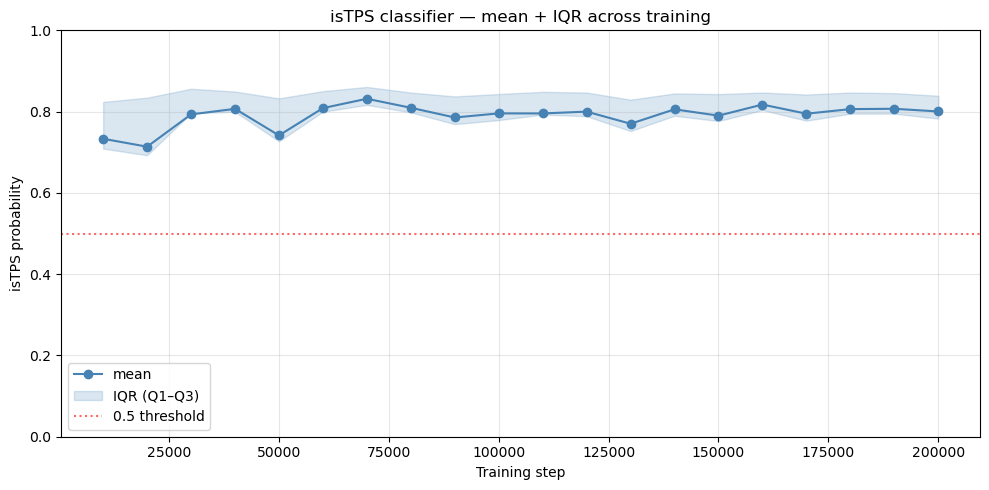

In [5]:
# Mean isTPS probability across training, with IQR band.
isTPS_mean, isTPS_q1, isTPS_q3, n_seqs = [], [], [], []
for s in STEPS:
    df = ee[s]
    if df is None or "isTPS" not in df.columns:
        isTPS_mean.append(np.nan); isTPS_q1.append(np.nan); isTPS_q3.append(np.nan); n_seqs.append(0); continue
    v = df["isTPS"].values
    isTPS_mean.append(float(np.mean(v)))
    isTPS_q1.append(float(np.quantile(v, 0.25)))
    isTPS_q3.append(float(np.quantile(v, 0.75)))
    n_seqs.append(len(v))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(STEPS, isTPS_mean, marker="o", color="steelblue", label="mean")
ax.fill_between(STEPS, isTPS_q1, isTPS_q3, alpha=0.2, color="steelblue", label="IQR (Q1–Q3)")
ax.axhline(0.5, color="red", linestyle=":", alpha=0.6, label="0.5 threshold")
ax.set_xlabel("Training step"); ax.set_ylabel("isTPS probability")
ax.set_title("isTPS classifier — mean + IQR across training"); ax.set_ylim(0, 1)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

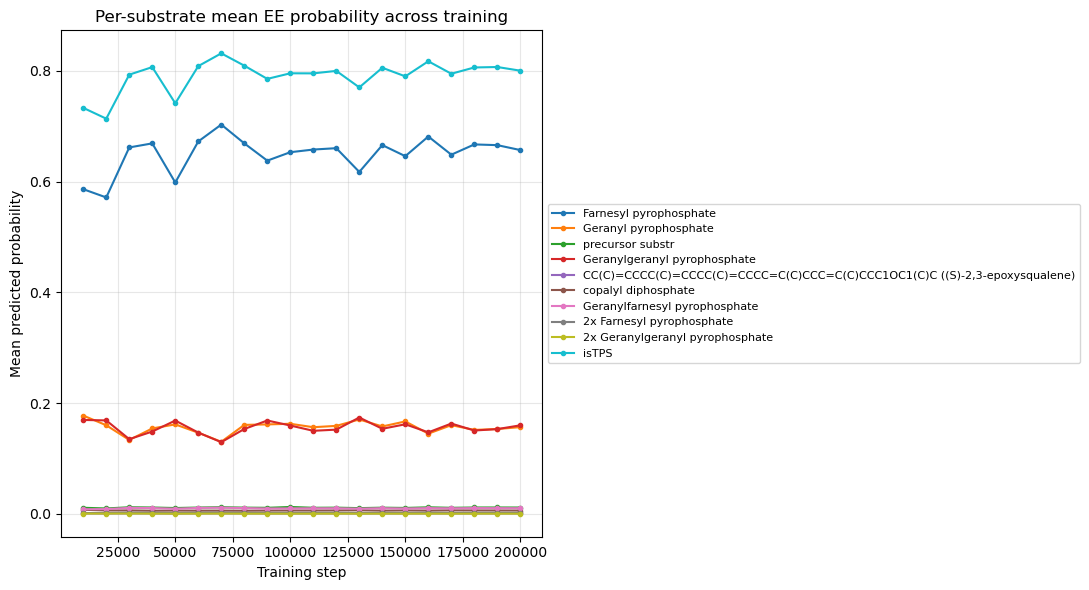

In [6]:
# Per-substrate mean probability across training (multi-line).
fig, ax = plt.subplots(figsize=(11, 6))
for col in EE_COLS:
    if col == "ID": continue
    means = [float(np.mean(ee[s][col].values)) if (ee[s] is not None and col in ee[s].columns) else np.nan for s in STEPS]
    ax.plot(STEPS, means, marker=".", label=EE_SHORT.get(col, col))
ax.set_xlabel("Training step"); ax.set_ylabel("Mean predicted probability")
ax.set_title("Per-substrate mean EE probability across training")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

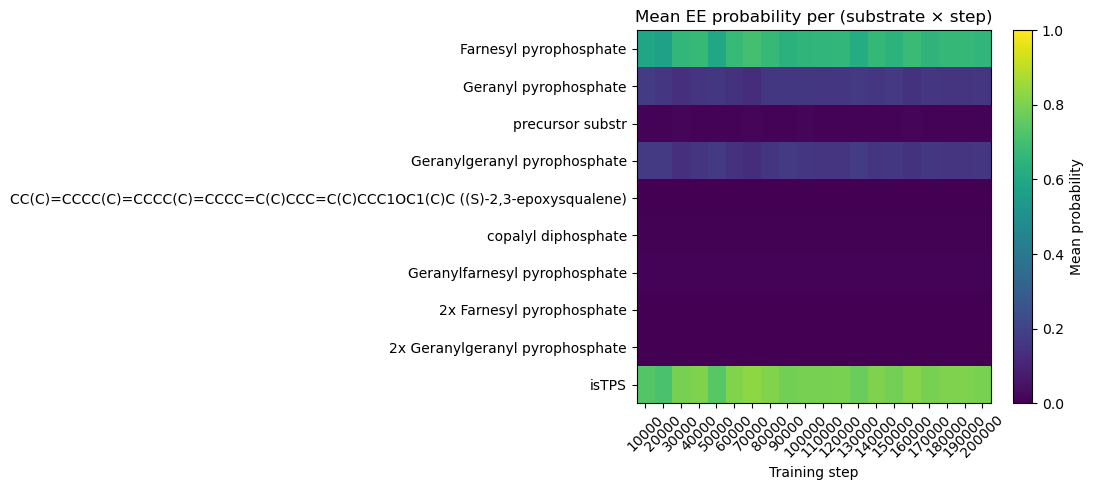

In [7]:
# Heatmap of substrate × step (mean probability).
data = []; labels = []
for col in EE_COLS:
    if col == "ID": continue
    means = [float(np.mean(ee[s][col].values)) if (ee[s] is not None and col in ee[s].columns) else np.nan for s in STEPS]
    data.append(means); labels.append(EE_SHORT.get(col, col))
heatmap = np.array(data)

fig, ax = plt.subplots(figsize=(11, max(3, 0.4 * len(labels) + 1)))
im = ax.imshow(heatmap, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(STEPS))); ax.set_xticklabels([str(s) for s in STEPS], rotation=45)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Training step")
ax.set_title("Mean EE probability per (substrate × step)")
plt.colorbar(im, ax=ax, label="Mean probability")
plt.tight_layout(); plt.show()

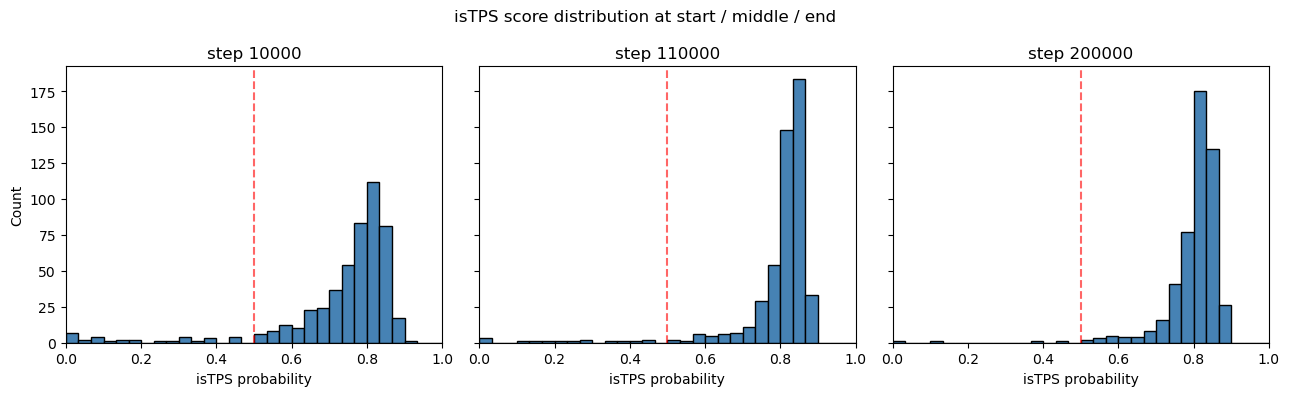

In [8]:
# Distribution of isTPS scores at three checkpoints (start / middle / end).
sample_steps = [STEPS[0], STEPS[len(STEPS)//2], STEPS[-1]]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, s in zip(axes, sample_steps):
    df = ee[s]
    if df is None or "isTPS" not in df.columns:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes); continue
    ax.hist(df["isTPS"].values, bins=30, range=(0, 1), color="steelblue", edgecolor="black")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.6)
    ax.set_xlabel("isTPS probability"); ax.set_title(f"step {s}"); ax.set_xlim(0, 1)
axes[0].set_ylabel("Count")
plt.suptitle("isTPS score distribution at start / middle / end")
plt.tight_layout(); plt.show()

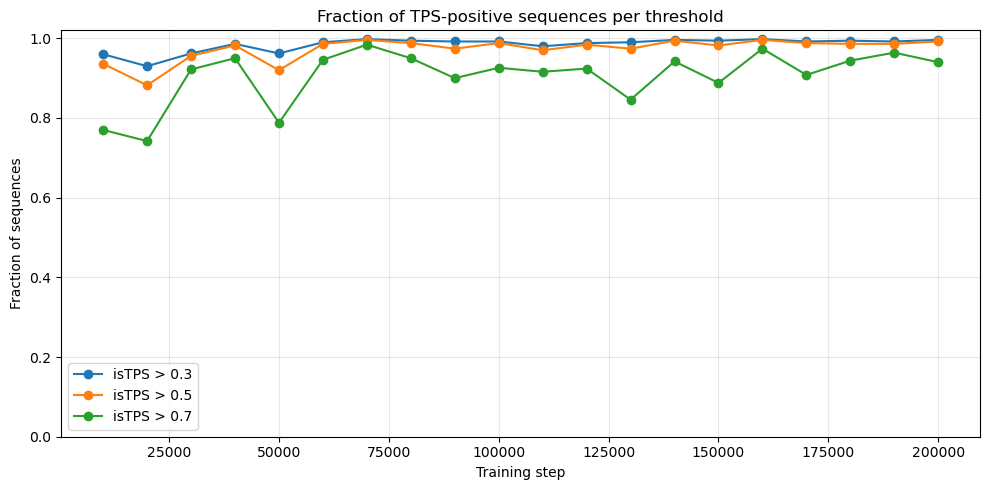

In [9]:
# Fraction of sequences classified as TPS (isTPS > threshold) across training.
THRESHOLDS = [0.3, 0.5, 0.7]
fig, ax = plt.subplots(figsize=(10, 5))
for th in THRESHOLDS:
    fracs = []
    for s in STEPS:
        df = ee[s]
        if df is None or "isTPS" not in df.columns:
            fracs.append(np.nan); continue
        fracs.append(float((df["isTPS"].values > th).mean()))
    ax.plot(STEPS, fracs, marker="o", label=f"isTPS > {th}")
ax.set_xlabel("Training step"); ax.set_ylabel("Fraction of sequences")
ax.set_title("Fraction of TPS-positive sequences per threshold")
ax.set_ylim(0, 1.02); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2 · Sequence identity vs training set

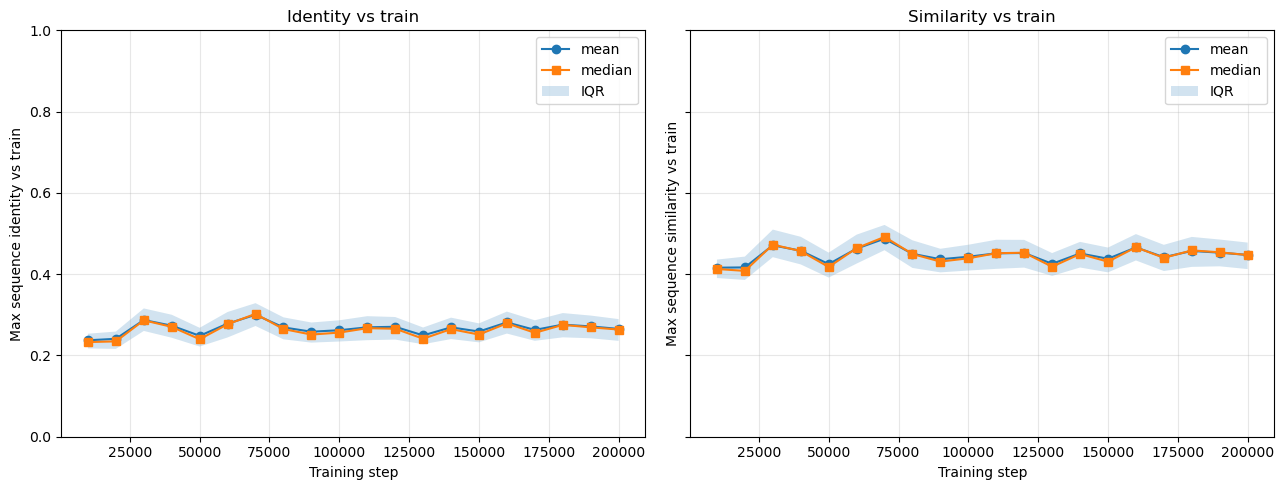

In [10]:
def _stats(df, col):
    if df is None or col not in df.columns:
        return [np.nan]*4
    v = df[col].values
    return [float(np.mean(v)), float(np.median(v)), float(np.quantile(v, 0.25)), float(np.quantile(v, 0.75))]

id_mean=[]; id_med=[]; id_q1=[]; id_q3=[]
sim_mean=[]; sim_med=[]; sim_q1=[]; sim_q3=[]
for s in STEPS:
    a, b, c, d = _stats(msi_train[s], "sequence_identity");   id_mean.append(a);  id_med.append(b);  id_q1.append(c);  id_q3.append(d)
    a, b, c, d = _stats(msi_train[s], "sequence_similarity"); sim_mean.append(a); sim_med.append(b); sim_q1.append(c); sim_q3.append(d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ax = axes[0]
ax.plot(STEPS, id_mean,  marker="o", label="mean")
ax.plot(STEPS, id_med,   marker="s", label="median")
ax.fill_between(STEPS, id_q1, id_q3, alpha=0.2, label="IQR")
ax.set_xlabel("Training step"); ax.set_ylabel("Max sequence identity vs train")
ax.set_title("Identity vs train"); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1]
ax.plot(STEPS, sim_mean, marker="o", label="mean")
ax.plot(STEPS, sim_med,  marker="s", label="median")
ax.fill_between(STEPS, sim_q1, sim_q3, alpha=0.2, label="IQR")
ax.set_xlabel("Training step"); ax.set_ylabel("Max sequence similarity vs train")
ax.set_title("Similarity vs train"); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

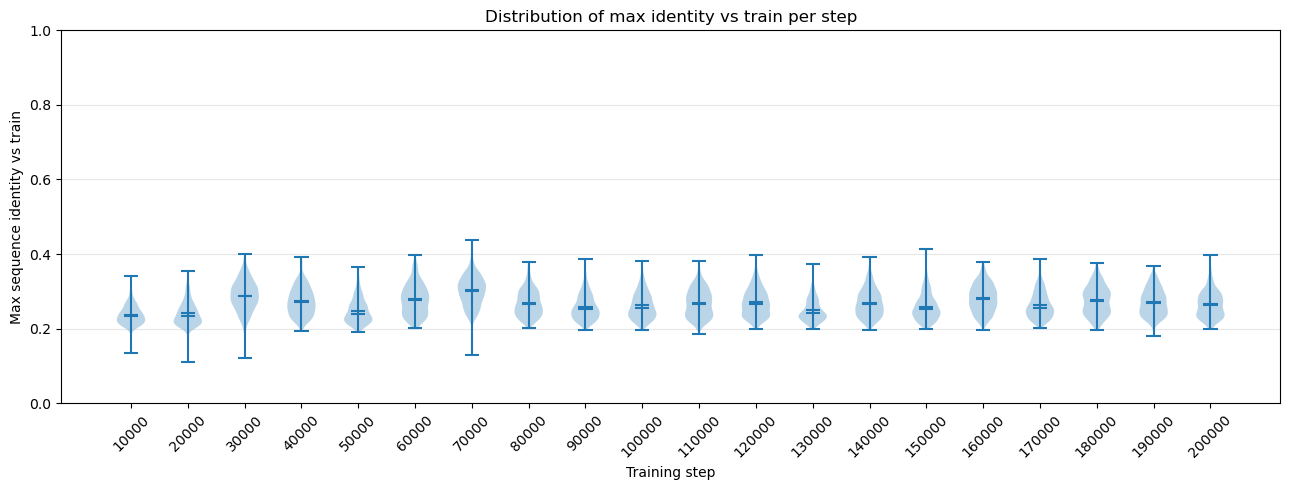

In [11]:
# Per-step distribution as a violin plot of identity-vs-train.
data = []; labs = []
for s in STEPS:
    df = msi_train[s]
    if df is None or "sequence_identity" not in df.columns: continue
    data.append(df["sequence_identity"].values); labs.append(str(s))

fig, ax = plt.subplots(figsize=(13, 5))
if data:
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    ax.set_xticks(range(1, len(labs) + 1))
    ax.set_xticklabels(labs, rotation=45)
    ax.set_xlabel("Training step"); ax.set_ylabel("Max sequence identity vs train")
    ax.set_title("Distribution of max identity vs train per step"); ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()

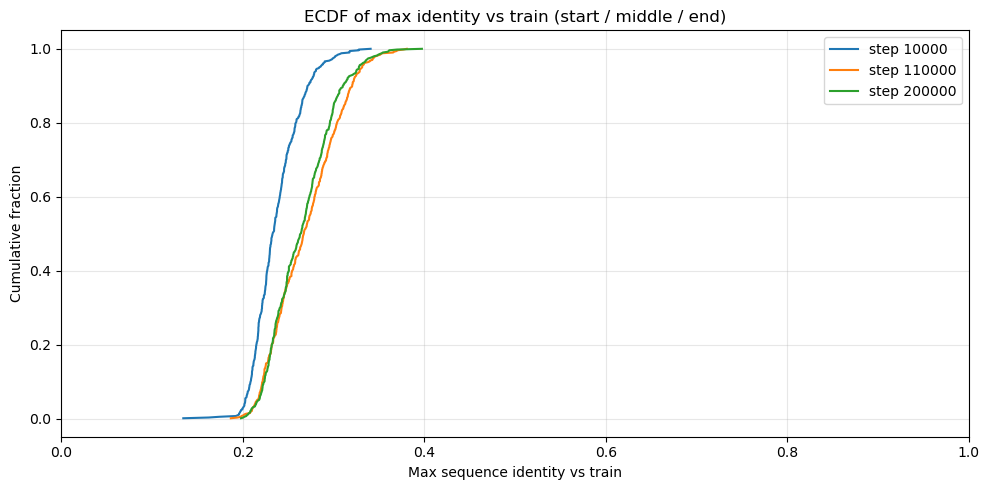

In [12]:
# ECDF of identity-vs-train at start / middle / end.
fig, ax = plt.subplots(figsize=(10, 5))
for s in [STEPS[0], STEPS[len(STEPS)//2], STEPS[-1]]:
    df = msi_train[s]
    if df is None or "sequence_identity" not in df.columns: continue
    vals = np.sort(df["sequence_identity"].values)
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, label=f"step {s}")
ax.set_xlabel("Max sequence identity vs train"); ax.set_ylabel("Cumulative fraction")
ax.set_title("ECDF of max identity vs train (start / middle / end)")
ax.set_xlim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3 · Self identity (mode-collapse signal)

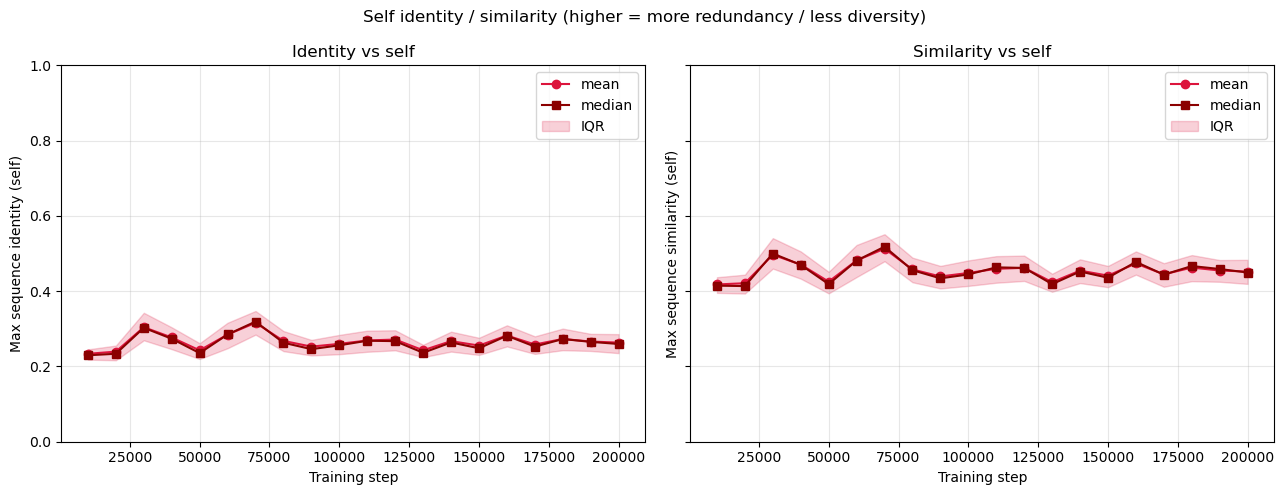

In [13]:
# Mean / median self-identity and self-similarity per step (two panels).
self_id_mean=[]; self_id_med=[]; self_id_q1=[]; self_id_q3=[]
self_sim_mean=[]; self_sim_med=[]; self_sim_q1=[]; self_sim_q3=[]
for s in STEPS:
    a, b, c, d = _stats(msi_self[s], "sequence_identity")
    self_id_mean.append(a); self_id_med.append(b); self_id_q1.append(c); self_id_q3.append(d)
    a, b, c, d = _stats(msi_self[s], "sequence_similarity")
    self_sim_mean.append(a); self_sim_med.append(b); self_sim_q1.append(c); self_sim_q3.append(d)

# Backwards-compat aliases for downstream cells.
self_mean = self_id_mean; self_med = self_id_med; self_q1 = self_id_q1; self_q3 = self_id_q3

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ax = axes[0]
ax.plot(STEPS, self_id_mean, marker="o", color="crimson", label="mean")
ax.plot(STEPS, self_id_med,  marker="s", color="darkred",  label="median")
ax.fill_between(STEPS, self_id_q1, self_id_q3, alpha=0.2, color="crimson", label="IQR")
ax.set_xlabel("Training step"); ax.set_ylabel("Max sequence identity (self)")
ax.set_title("Identity vs self"); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1]
ax.plot(STEPS, self_sim_mean, marker="o", color="crimson", label="mean")
ax.plot(STEPS, self_sim_med,  marker="s", color="darkred",  label="median")
ax.fill_between(STEPS, self_sim_q1, self_sim_q3, alpha=0.2, color="crimson", label="IQR")
ax.set_xlabel("Training step"); ax.set_ylabel("Max sequence similarity (self)")
ax.set_title("Similarity vs self"); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Self identity / similarity (higher = more redundancy / less diversity)")
plt.tight_layout(); plt.show()


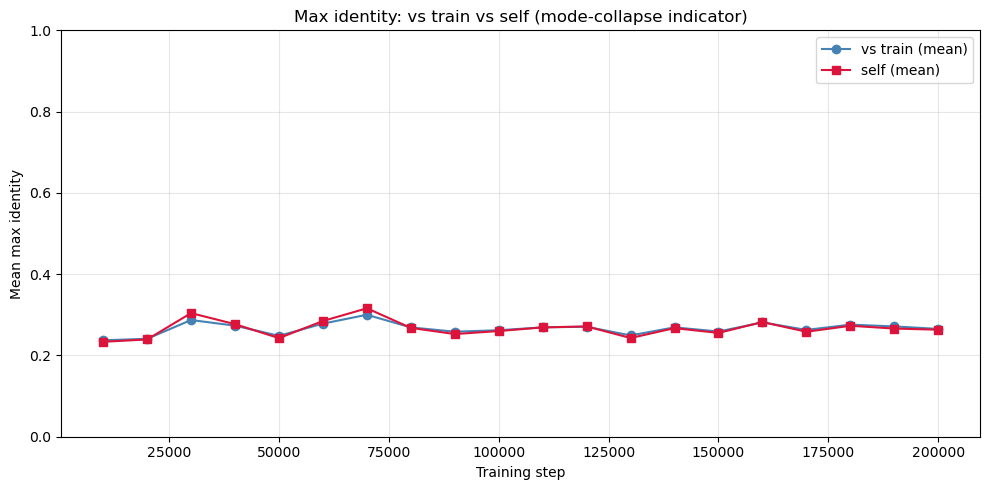

In [14]:
# Overlay: max identity vs train vs max self-identity.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(STEPS, id_mean,   marker="o", color="steelblue", label="vs train (mean)")
ax.plot(STEPS, self_mean, marker="s", color="crimson",   label="self (mean)")
ax.set_xlabel("Training step"); ax.set_ylabel("Mean max identity"); ax.set_ylim(0, 1)
ax.set_title("Max identity: vs train vs self (mode-collapse indicator)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

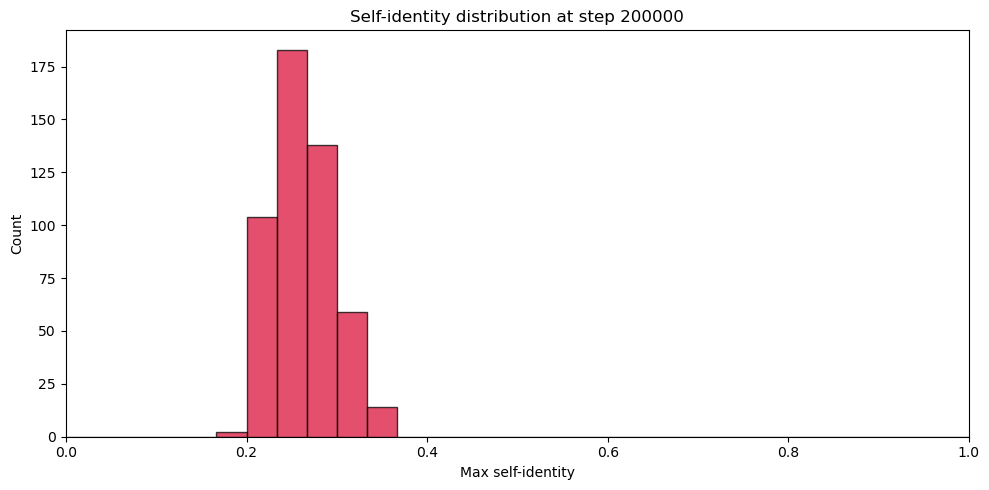

In [15]:
# Self-identity histogram at the final checkpoint.
fig, ax = plt.subplots(figsize=(10, 5))
df = msi_self.get(STEPS[-1])
if df is not None and "sequence_identity" in df.columns:
    ax.hist(df["sequence_identity"].values, bins=30, range=(0, 1), color="crimson", edgecolor="black", alpha=0.75)
    ax.set_xlabel("Max self-identity"); ax.set_ylabel("Count")
    ax.set_title(f"Self-identity distribution at step {STEPS[-1]}")
    ax.set_xlim(0, 1)
else:
    ax.text(0.5, 0.5, "no data for final step", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()

## 4 · Motif occurrence

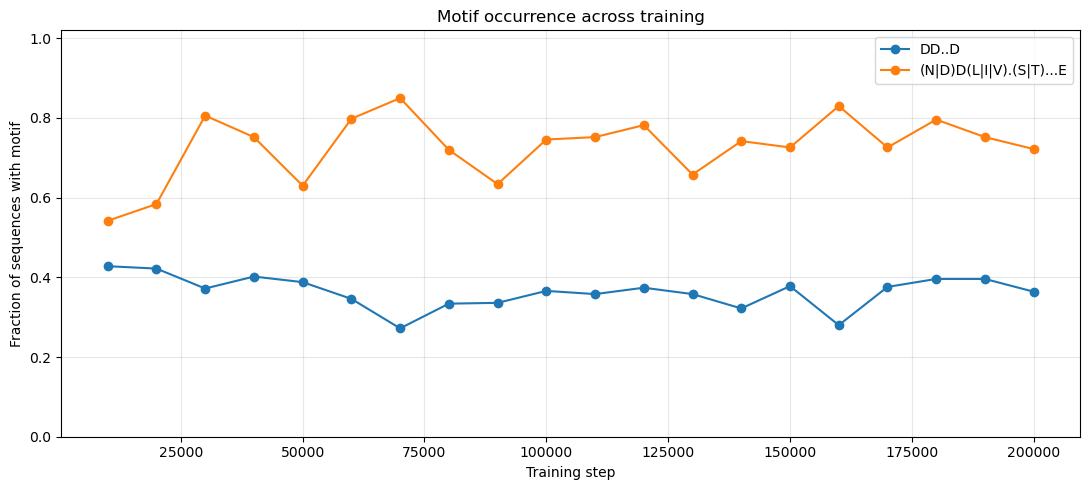

In [16]:
# Fraction of sequences containing each motif, across training.
fig, ax = plt.subplots(figsize=(11, 5))
for col in MOTIF_COLS:
    fracs = []
    for s in STEPS:
        df = motif[s]
        if df is None or col not in df.columns:
            fracs.append(np.nan); continue
        fracs.append(float(df[col].astype(bool).mean()))
    ax.plot(STEPS, fracs, marker="o", label=col)
ax.set_xlabel("Training step"); ax.set_ylabel("Fraction of sequences with motif")
ax.set_title("Motif occurrence across training")
ax.set_ylim(0, 1.02); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

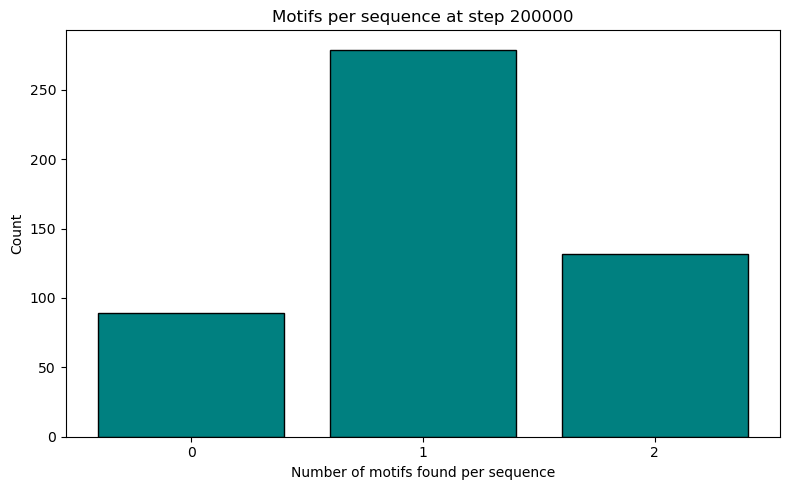

In [17]:
# Distribution of N-motifs-per-sequence at the final checkpoint.
fig, ax = plt.subplots(figsize=(8, 5))
df = motif.get(STEPS[-1])
if df is not None and MOTIF_COLS:
    counts = df[MOTIF_COLS].astype(bool).sum(axis=1)
    ax.hist(counts, bins=range(len(MOTIF_COLS) + 2), align="left", rwidth=0.8, color="teal", edgecolor="black")
    ax.set_xlabel("Number of motifs found per sequence")
    ax.set_ylabel("Count")
    ax.set_title(f"Motifs per sequence at step {STEPS[-1]}")
    ax.set_xticks(range(len(MOTIF_COLS) + 1))
else:
    ax.text(0.5, 0.5, "no data for final step", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()

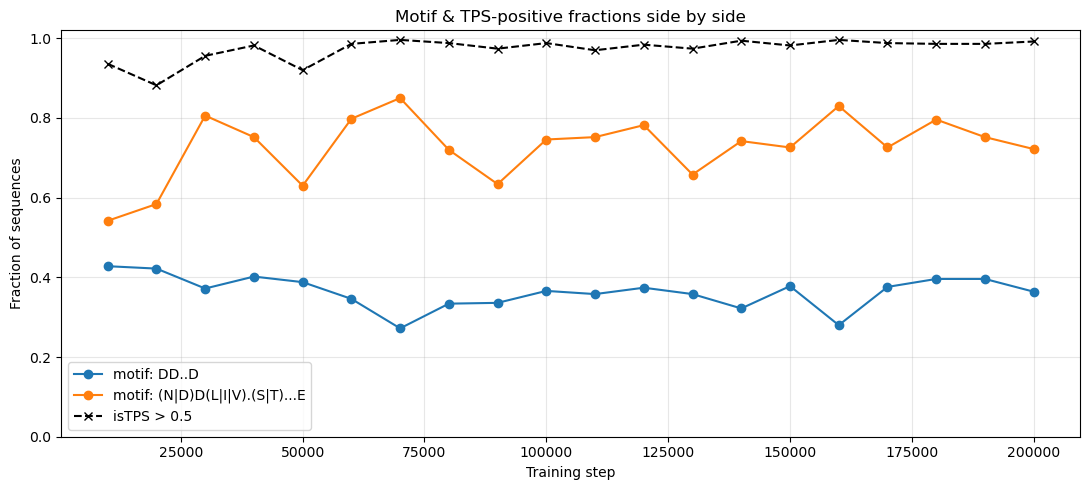

In [18]:
# Combined view: motif occurrence + isTPS-positive fraction.
fig, ax = plt.subplots(figsize=(11, 5))
for col in MOTIF_COLS:
    fracs = []
    for s in STEPS:
        df = motif[s]
        if df is None or col not in df.columns:
            fracs.append(np.nan); continue
        fracs.append(float(df[col].astype(bool).mean()))
    ax.plot(STEPS, fracs, marker="o", label=f"motif: {col}")

# Add isTPS-positive fraction (threshold 0.5) on the same axes.
isTPS_pos = []
for s in STEPS:
    df = ee[s]
    if df is None or "isTPS" not in df.columns:
        isTPS_pos.append(np.nan); continue
    isTPS_pos.append(float((df["isTPS"].values > 0.5).mean()))
ax.plot(STEPS, isTPS_pos, marker="x", linestyle="--", color="black", label="isTPS > 0.5")

ax.set_xlabel("Training step"); ax.set_ylabel("Fraction of sequences")
ax.set_title("Motif & TPS-positive fractions side by side")
ax.set_ylim(0, 1.02); ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Aggregate summary table

In [19]:
rows = []
for s in STEPS:
    row = {"step": s}
    df = ee[s]
    if df is not None:
        if "isTPS" in df.columns:
            row["isTPS_mean"]    = round(float(df["isTPS"].mean()), 3)
            row["isTPS_pos@0.5"] = round(float((df["isTPS"] > 0.5).mean()), 3)
    df = msi_train[s]
    if df is not None and "sequence_identity" in df.columns:
        row["id_train_mean"]    = round(float(df["sequence_identity"].mean()), 3)
        row["id_train_median"]  = round(float(df["sequence_identity"].median()), 3)
    df = msi_self[s]
    if df is not None and "sequence_identity" in df.columns:
        row["id_self_mean"]   = round(float(df["sequence_identity"].mean()), 3)
        row["id_self_median"] = round(float(df["sequence_identity"].median()), 3)
    df = motif[s]
    if df is not None and MOTIF_COLS:
        for col in MOTIF_COLS:
            row[f"motif:{col}"] = round(float(df[col].astype(bool).mean()), 3)
    rows.append(row)

summary = pd.DataFrame(rows).set_index("step")
print(summary.to_string())
summary

        isTPS_mean  isTPS_pos@0.5  id_train_mean  id_train_median  id_self_mean  id_self_median  motif:DD..D  motif:(N|D)D(L|I|V).(S|T)...E
step                                                                                                                                       
10000        0.733          0.936          0.237            0.233         0.234           0.230        0.428                          0.542
20000        0.714          0.882          0.241            0.235         0.239           0.234        0.422                          0.584
30000        0.793          0.956          0.287            0.287         0.304           0.303        0.372                          0.806
40000        0.807          0.982          0.273            0.270         0.277           0.274        0.402                          0.752
50000        0.741          0.920          0.248            0.240         0.243           0.235        0.388                          0.630
60000        0.809  

,isTPS_mean,isTPS_pos@0.5,id_train_mean,id_train_median,id_self_mean,id_self_median,motif:DD..D,motif:(N|D)D(L|I|V).(S|T)...E
step,,,,,,,,
10000,0.733,0.936,0.237,0.233,0.234,0.230,0.428,0.542
20000,0.714,0.882,0.241,0.235,0.239,0.234,0.422,0.584
30000,0.793,0.956,0.287,0.287,0.304,0.303,0.372,0.806
40000,0.807,0.982,0.273,0.270,0.277,0.274,0.402,0.752
50000,0.741,0.920,0.248,0.240,0.243,0.235,0.388,0.630
60000,0.809,0.986,0.278,0.277,0.285,0.285,0.346,0.798
70000,0.832,0.996,0.300,0.302,0.316,0.319,0.272,0.850
80000,0.809,0.988,0.269,0.265,0.268,0.263,0.334,0.720
90000,0.786,0.974,0.258,0.251,0.253,0.246,0.336,0.634
